# XGBoost com Features de Cluster — Predição de Churn
## PRT Seguros

Modelo XGBoost que usa os clusters de comportamento descobertos pela clusterização K-Means como feature adicional.

**Lógica:** o cluster comprime de forma não-linear as **30 variáveis** usadas no K-Means,  
codificando segmentos de risco comportamental que o XGBoost pode explorar junto às features individuais.

**Fluxo:**
1. Carregar base unificada
2. Re-executar K-Means (mesmo K do notebook de clusterização) e adicionar coluna `cluster`
3. Preparar features, tratar nulos
4. Treinar XGBoost **com** e **sem** feature de cluster
5. Comparar métricas entre si e contra Random Forest (AUC baseline = 0.8176)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

import xgboost as xgb

PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"
RANDOM_STATE = 42

print(f"XGBoost versão: {xgb.__version__}")

XGBoost versão: 3.3.0


## 2. Carregar dados

In [2]:
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Tratada.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (81881, 84)


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,...,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,churned,num_apolices_premium,num_apolices_basica,num_apolices_padrao
0,221300904264,2.0,2316.72,2339.0,01/05/2020,5.0,201525.43,2446.83,1.0,0.066,...,0,0,0,0,0,0,0,2.0,0.0,0.0
1,221300318278,3.0,NaN,1648.0,26/11/2021,1.0,NaN,NaN,1.0,0.103,...,0,1,0,0,0,0,0,0.0,3.0,0.0
2,221302854940,NaN,1033.15,187.0,26/11/2025,5.0,196256.43,951.09,1.0,0.050,...,0,0,0,0,0,0,0,NaN,NaN,NaN


## 3. Re-executar K-Means e criar feature `cluster`

Reproduzimos exatamente o mesmo K-Means do notebook de clusterização (mesmas 30 features, mesma semente, mesmo K).  
O cluster vira uma **feature inteira** para o XGBoost — árvores de decisão lidam com splits em inteiros naturalmente,  
sem necessidade de one-hot encoding.

In [3]:
FEATURES_CLUSTER = [
    # |corr| > 0.10
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "desconto_aplicado_pct", "indice_relacionamento", "num_apolices_basica",
    "satisfacao_nps", "tipo_cobertura_basica", "estado_civil", "tipo_cobertura_premium",
    "tem_filhos", "renda_anual", "qtd_dependentes", "valor_imovel",
    # |corr| 0.02–0.10
    "num_apolices_premium", "valor_cobertura_total", "idade", "num_apolices_padrao",
    "score_engajamento_digital", "pagamento_em_dia", "num_reclamacoes_12m",
    "num_acessos_app_mes", "possui_imovel", "tipo_cobertura_padrao",
    # |corr| 0.01–0.02
    "valor_premio_anual", "franquia_media",
]

K_FINAL = 4  # ajuste após rodar o cotovelo no notebook de clusterização com 26 features

X_c = df[FEATURES_CLUSTER].copy()
imp_c = SimpleImputer(strategy="median")
X_c_imp = imp_c.fit_transform(X_c)
scaler_c = StandardScaler()
X_c_scaled = scaler_c.fit_transform(X_c_imp)

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_c_scaled)

churn_cluster = df.groupby("cluster")["churned"].agg(["mean", "count"])
churn_cluster.columns = ["taxa_churn", "n_clientes"]
churn_cluster["taxa_churn_pct"] = (churn_cluster["taxa_churn"] * 100).round(1)
print(f"K = {K_FINAL} clusters | {len(FEATURES_CLUSTER)} features")
print(churn_cluster.sort_values("taxa_churn", ascending=False))

K = 4 clusters | 26 features
         taxa_churn  n_clientes  taxa_churn_pct
cluster                                        
2          0.217186       25172            21.7
3          0.213702       12480            21.4
0          0.044088       22160             4.4
1          0.036114       22069             3.6


## 4. Limpar colunas de leakage, datas e multicolinearidade

In [4]:
# Leakage: variáveis derivadas do próprio churn
colunas_leakage = ["score_propensao_churn", "cluster_sugerido_crm"]
presentes = [c for c in colunas_leakage if c in df.columns]
if presentes:
    print(f"Removendo leakage: {presentes}")
    df = df.drop(columns=presentes)

# Datas em string não servem como feature numérica
colunas_data = ["data_primeira_apolice", "data_nascimento"]
presentes_data = [c for c in colunas_data if c in df.columns]
if presentes_data:
    print(f"Removendo datas: {presentes_data}")
    df = df.drop(columns=presentes_data)

# Multicolinearidade alta com tempo_cliente_dias
if "renovacoes_consecutivas" in df.columns:
    corr = df[["tempo_cliente_dias", "renovacoes_consecutivas"]].corr().iloc[0, 1]
    print(f"Correlação tempo_cliente_dias × renovacoes_consecutivas: {corr:.3f} → removendo")
    df = df.drop(columns=["renovacoes_consecutivas"])

print(f"Shape após limpeza: {df.shape}")

Removendo leakage: ['score_propensao_churn', 'cluster_sugerido_crm']
Removendo datas: ['data_primeira_apolice', 'data_nascimento']
Correlação tempo_cliente_dias × renovacoes_consecutivas: 0.942 → removendo
Shape após limpeza: (81881, 80)


## 5. Definir X e y — duas versões (com e sem cluster)

In [5]:
TARGET = "churned"
y = df[TARGET]

# Remove target e identificador
X_base = df.drop(columns=[TARGET, "cod_individuo"], errors="ignore")

# Tratar colunas object residuais
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()
if cat_cols:
    print(f"Encoding one-hot: {cat_cols}")
    X_base = pd.get_dummies(X_base, columns=cat_cols, drop_first=True)

# Versão SEM cluster
X_sem_cluster = X_base.drop(columns=["cluster"], errors="ignore")

# Versão COM cluster
X_com_cluster = X_base.copy()

print(f"Features sem cluster : {X_sem_cluster.shape[1]}")
print(f"Features com cluster : {X_com_cluster.shape[1]}")
print(f"Churn rate           : {y.mean():.2%}")

Features sem cluster : 77
Features com cluster : 78
Churn rate           : 12.10%


## 6. Imputar nulos e fazer train/test split

XGBoost suporta NaN nativamente no treinamento, mas a API do sklearn exige arrays sem nulos.  
Usamos imputação por mediana, igual aos modelos anteriores.

In [6]:
imputer = SimpleImputer(strategy="median")

# Sem cluster
X_sem_imp = pd.DataFrame(
    imputer.fit_transform(X_sem_cluster),
    columns=X_sem_cluster.columns
)

# Com cluster — fit separado para não vazar info
imputer2 = SimpleImputer(strategy="median")
X_com_imp = pd.DataFrame(
    imputer2.fit_transform(X_com_cluster),
    columns=X_com_cluster.columns
)

# Split estratificado (mantém proporção de churn)
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_sem_imp, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train_c, X_test_c, _, _ = train_test_split(
    X_com_imp, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Peso para balancear classes (equivalente a class_weight='balanced')
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Treino : {X_train_s.shape[0]:,} amostras | churn = {y_train.mean():.1%}")
print(f"Teste  : {X_test_s.shape[0]:,} amostras | churn = {y_test.mean():.1%}")
print(f"scale_pos_weight (neg/pos ratio) = {neg_pos_ratio:.1f}")

Treino : 65,504 amostras | churn = 12.1%
Teste  : 16,377 amostras | churn = 12.1%
scale_pos_weight (neg/pos ratio) = 7.3


## 7. Treinar XGBoost — sem cluster (baseline XGB)

Hiperparâmetros iniciais seguros para dados tabulares com ~82k linhas:

| Parâmetro | Valor | Por quê |
|---|---|---|
| `n_estimators` | 500 | 500 árvores sequenciais |
| `max_depth` | 5 | Árvores médias — evita overfitting |
| `learning_rate` | 0.05 | Passos pequenos = modelo mais robusto |
| `subsample` | 0.8 | 80% das linhas por árvore (regularização) |
| `colsample_bytree` | 0.8 | 80% das features por árvore (regularização) |
| `scale_pos_weight` | neg/pos | Compensa desbalanceamento de classes |
| `tree_method` | hist | Algoritmo rápido para grandes datasets |

In [7]:
xgb_sem = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    tree_method="hist",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Treinando XGBoost sem cluster...")
xgb_sem.fit(
    X_train_s, y_train,
    eval_set=[(X_test_s, y_test)],
    verbose=100,
)

y_proba_sem = xgb_sem.predict_proba(X_test_s)[:, 1]
y_pred_sem  = xgb_sem.predict(X_test_s)
auc_sem = roc_auc_score(y_test, y_proba_sem)

print(f"\n{'='*55}")
print("XGBoost SEM cluster — RESULTADOS")
print('='*55)
print(classification_report(y_test, y_pred_sem, target_names=["Não-churn", "Churn"]))
print(f"ROC-AUC : {auc_sem:.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_proba_sem):.4f}")

Treinando XGBoost sem cluster...
[0]	validation_0-auc:0.81813
[100]	validation_0-auc:0.82660
[200]	validation_0-auc:0.82510
[300]	validation_0-auc:0.82369
[400]	validation_0-auc:0.82131
[499]	validation_0-auc:0.81946

XGBoost SEM cluster — RESULTADOS
              precision    recall  f1-score   support

   Não-churn       0.95      0.79      0.86     14395
       Churn       0.32      0.70      0.44      1982

    accuracy                           0.78     16377
   macro avg       0.63      0.75      0.65     16377
weighted avg       0.87      0.78      0.81     16377

ROC-AUC : 0.8195
Avg Precision: 0.4139


## 8. Treinar XGBoost — com cluster

In [8]:
xgb_com = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    tree_method="hist",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Treinando XGBoost com cluster...")
xgb_com.fit(
    X_train_c, y_train,
    eval_set=[(X_test_c, y_test)],
    verbose=100,
)

y_proba_com = xgb_com.predict_proba(X_test_c)[:, 1]
y_pred_com  = xgb_com.predict(X_test_c)
auc_com = roc_auc_score(y_test, y_proba_com)

print(f"\n{'='*55}")
print("XGBoost COM cluster — RESULTADOS")
print('='*55)
print(classification_report(y_test, y_pred_com, target_names=["Não-churn", "Churn"]))
print(f"ROC-AUC : {auc_com:.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_proba_com):.4f}")

Treinando XGBoost com cluster...
[0]	validation_0-auc:0.81865
[100]	validation_0-auc:0.82548
[200]	validation_0-auc:0.82439
[300]	validation_0-auc:0.82256
[400]	validation_0-auc:0.82109
[499]	validation_0-auc:0.81981

XGBoost COM cluster — RESULTADOS
              precision    recall  f1-score   support

   Não-churn       0.95      0.79      0.86     14395
       Churn       0.32      0.70      0.44      1982

    accuracy                           0.78     16377
   macro avg       0.63      0.75      0.65     16377
weighted avg       0.87      0.78      0.81     16377

ROC-AUC : 0.8198
Avg Precision: 0.4106


## 9. Comparação — tabela de métricas

In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score

RF_AUC_BASELINE = 0.8176  # Random Forest — notebook random_forest_churn.ipynb

resultados = pd.DataFrame({
    "Modelo": [
        "Random Forest (baseline)",
        "XGBoost sem cluster",
        "XGBoost com cluster",
    ],
    "ROC-AUC": [
        RF_AUC_BASELINE,
        auc_sem,
        auc_com,
    ],
    "Precision (Churn)": [
        "-",
        f"{precision_score(y_test, y_pred_sem, pos_label=1):.3f}",
        f"{precision_score(y_test, y_pred_com, pos_label=1):.3f}",
    ],
    "Recall (Churn)": [
        "-",
        f"{recall_score(y_test, y_pred_sem, pos_label=1):.3f}",
        f"{recall_score(y_test, y_pred_com, pos_label=1):.3f}",
    ],
    "F1 (Churn)": [
        "-",
        f"{f1_score(y_test, y_pred_sem, pos_label=1):.3f}",
        f"{f1_score(y_test, y_pred_com, pos_label=1):.3f}",
    ],
})

print(resultados.to_string(index=False))

                  Modelo  ROC-AUC Precision (Churn) Recall (Churn) F1 (Churn)
Random Forest (baseline) 0.817600                 -              -          -
     XGBoost sem cluster 0.819459             0.319          0.705      0.439
     XGBoost com cluster 0.819814             0.317          0.699      0.436


## 10. Curva ROC — comparação dos três modelos

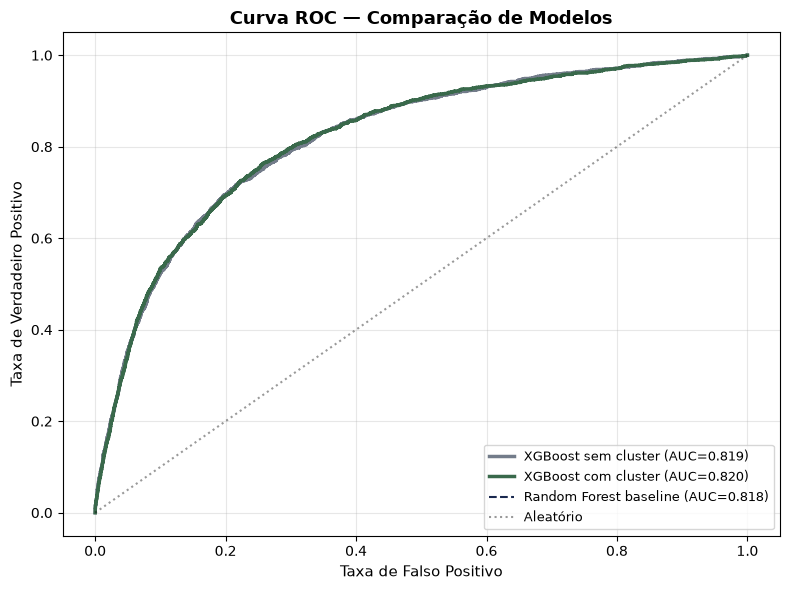

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_proba, label, cor in [
    (y_proba_sem, f"XGBoost sem cluster (AUC={auc_sem:.3f})", PRT_GRAY),
    (y_proba_com, f"XGBoost com cluster (AUC={auc_com:.3f})", PRT_GREEN),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=label, linewidth=2.5, color=cor)

# Linha do RF baseline
ax.axhline(y=0, color="none")  # dummy
ax.plot([], [], linestyle="--", color=PRT_NAVY,
        label=f"Random Forest baseline (AUC={RF_AUC_BASELINE:.3f})")

ax.plot([0, 1], [0, 1], linestyle=":", color="black", alpha=0.4, label="Aleatório")

ax.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax.set_title("Curva ROC — Comparação de Modelos", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Matriz de Confusão — XGBoost com cluster

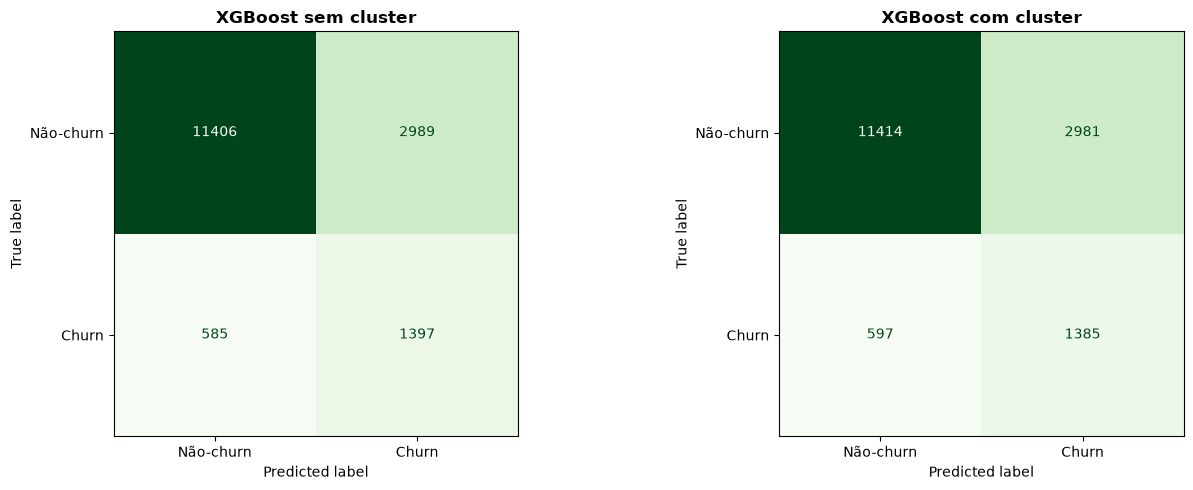

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in [
    (axes[0], y_pred_sem, "XGBoost sem cluster"),
    (axes[1], y_pred_com, "XGBoost com cluster"),
]:
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Não-churn", "Churn"]).plot(
        ax=ax, cmap="Greens", colorbar=False
    )
    ax.set_title(titulo, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## 12. Feature Importance — XGBoost com cluster

Usamos `importance_type='gain'` (ganho médio de informação por split) — mais estável que a contagem de splits (`weight`).

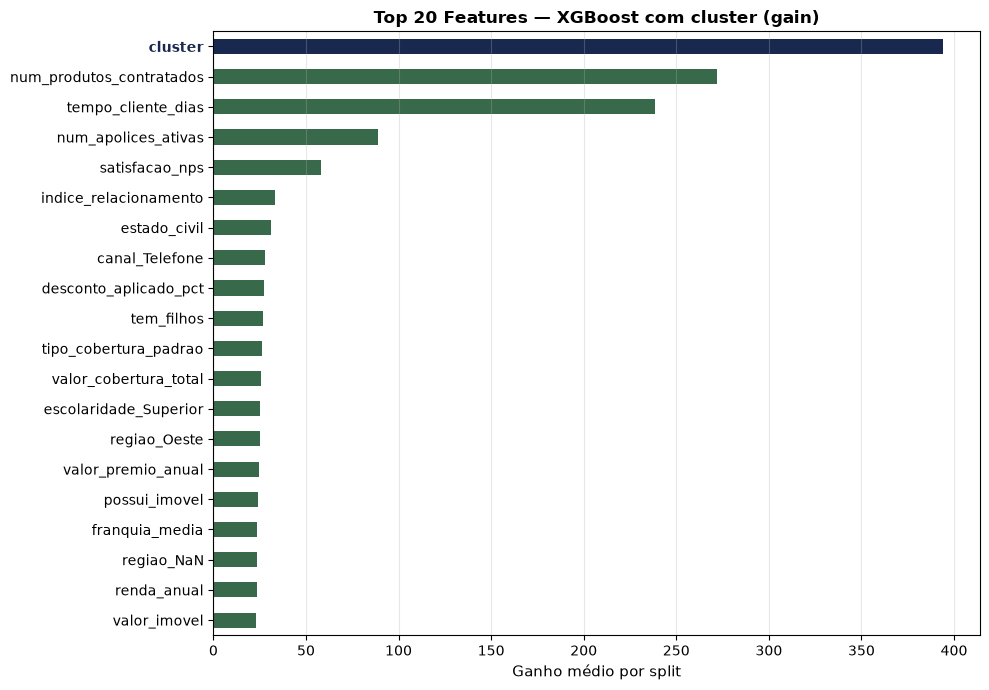


=== TOP 20 FEATURES (gain) ===
  cluster                             394.32 ◀ cluster
  num_produtos_contratados            272.15
  tempo_cliente_dias                  238.70
  num_apolices_ativas                 88.98
  satisfacao_nps                      58.10
  indice_relacionamento               33.10
  estado_civil                        31.23
  canal_Telefone                      27.67
  desconto_aplicado_pct               27.18
  tem_filhos                          26.68
  tipo_cobertura_padrao               26.04
  valor_cobertura_total               25.79
  escolaridade_Superior               25.26
  regiao_Oeste                        25.11
  valor_premio_anual                  24.42
  possui_imovel                       23.95
  franquia_media                      23.70
  regiao_NaN                          23.64
  renda_anual                         23.48
  valor_imovel                        23.11


In [12]:
importances = pd.Series(
    xgb_com.get_booster().get_score(importance_type="gain"),
).sort_values(ascending=False)

top20 = importances.head(20)

# Destacar o cluster na cor navy
cores = [PRT_NAVY if f == "cluster" else PRT_GREEN for f in top20.index[::-1]]

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind="barh", ax=ax, color=cores)
ax.set_title("Top 20 Features — XGBoost com cluster (gain)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Ganho médio por split", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")

# Anotação do cluster
if "cluster" in top20.index:
    pos = list(top20.sort_values().index).index("cluster")
    ax.get_yticklabels()[pos].set_color(PRT_NAVY)
    ax.get_yticklabels()[pos].set_fontweight("bold")

plt.tight_layout()
plt.show()

print("\n=== TOP 20 FEATURES (gain) ===")
for feat, val in top20.items():
    marker = " ◀ cluster" if feat == "cluster" else ""
    print(f"  {feat:<35} {val:.2f}{marker}")

## 13. Curva de aprendizado — AUC por número de árvores

Mostra se o modelo está overfitting (treino sobe, teste cai) ou se ainda há ganho em adicionar mais árvores.

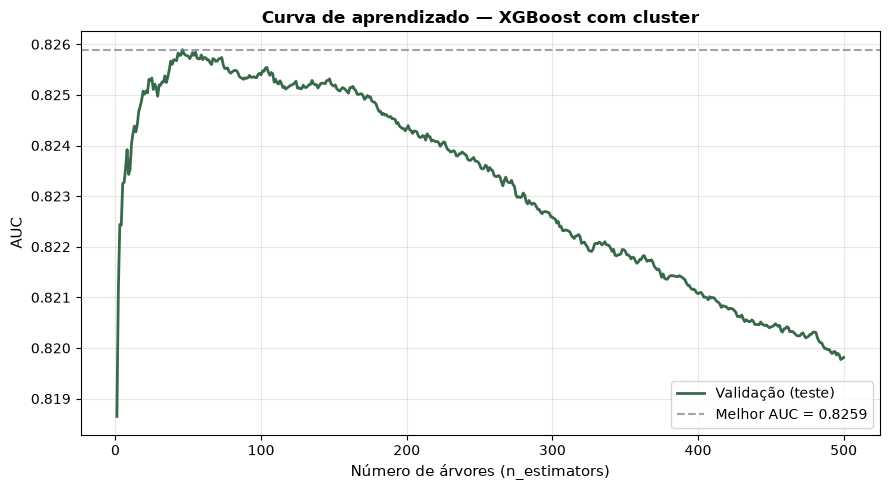

In [13]:
results = xgb_com.evals_result()
epochs  = range(1, len(results["validation_0"]["auc"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, results["validation_0"]["auc"],
        color=PRT_GREEN, linewidth=2, label="Validação (teste)")
ax.axhline(y=max(results["validation_0"]["auc"]),
           color=PRT_GRAY, linestyle="--", alpha=0.7,
           label=f"Melhor AUC = {max(results['validation_0']['auc']):.4f}")
ax.set_xlabel("Número de árvores (n_estimators)", fontsize=11)
ax.set_ylabel("AUC", fontsize=11)
ax.set_title("Curva de aprendizado — XGBoost com cluster", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Análise de risco por cluster — probabilidades preditas

Distribuição das probabilidades de churn por cluster — confirma se o modelo aprendeu a separar os segmentos de risco.

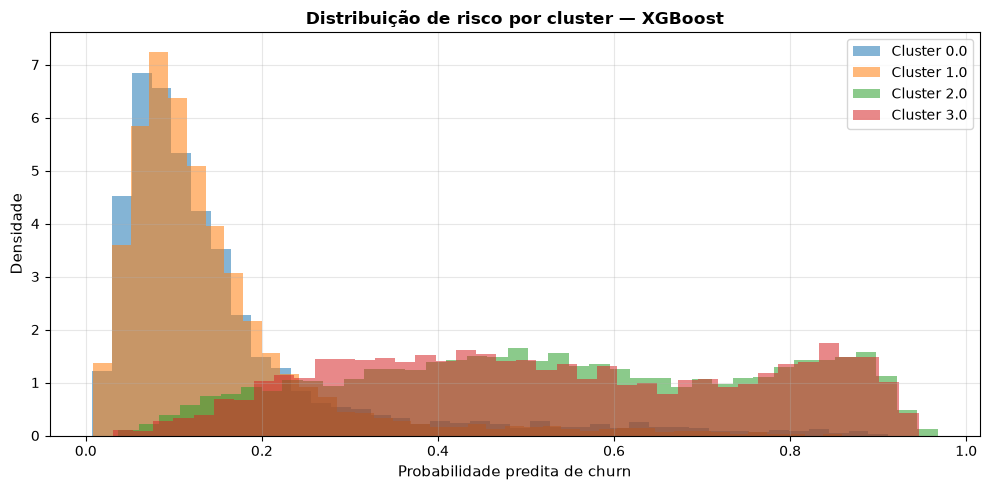


=== Probabilidade média de churn por cluster ===
          mean  median    std
cluster                      
0.0      0.158   0.110  0.151
1.0      0.144   0.112  0.118
2.0      0.537   0.530  0.232
3.0      0.531   0.510  0.231


In [14]:
df_test = X_test_c.copy()
df_test["proba_churn"] = y_proba_com
df_test["churned"]     = y_test.values

fig, ax = plt.subplots(figsize=(10, 5))
for cluster_id in sorted(df_test["cluster"].unique()):
    subset = df_test[df_test["cluster"] == cluster_id]["proba_churn"]
    ax.hist(subset, bins=40, alpha=0.55, label=f"Cluster {cluster_id}", density=True)

ax.set_xlabel("Probabilidade predita de churn", fontsize=11)
ax.set_ylabel("Densidade", fontsize=11)
ax.set_title("Distribuição de risco por cluster — XGBoost", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Probabilidade média de churn por cluster ===")
print(df_test.groupby("cluster")["proba_churn"].agg(["mean", "median", "std"]).round(3))